In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

---

# This is the final output we will get after our analysis:-

for US location:-

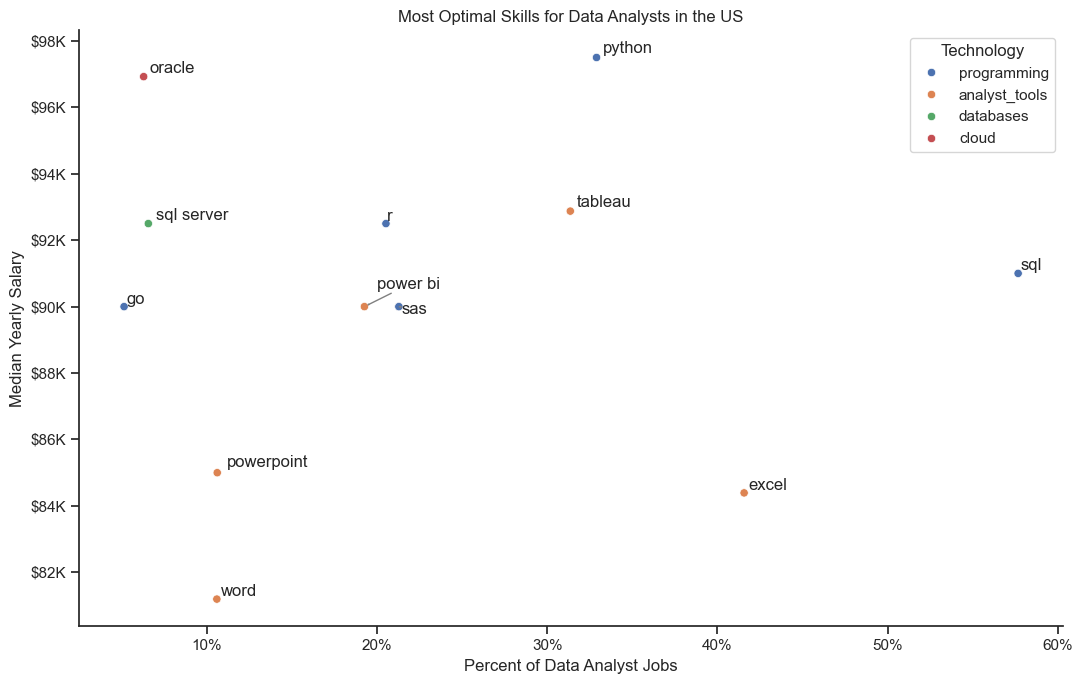

In [19]:
plt.figure(figsize=(11, 7)) # Increase figure size 
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()

---

for India location:-

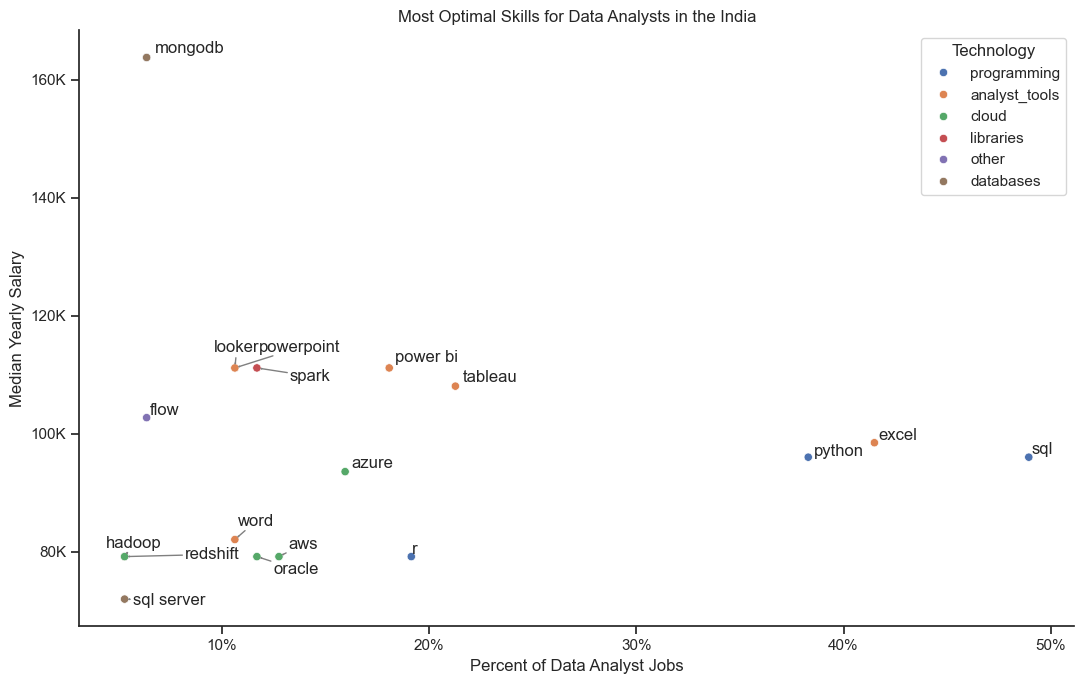

In [20]:
plt.figure(figsize=(11, 7)) # Increase figure size 
sns.scatterplot(
    data=df_ind_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_ind_skills_high_demand.index):
    texts.append(plt.text(df_da_ind_skills_high_demand['skill_percent'].iloc[i], df_da_ind_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the India')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()

---

# Below is the step by step procress which explains how i get these insights:-

What is the most optimal skill to learn for Data Analysts?

Methodology

Continue from last notebook to find percent of postings with skill

Visualize median salary vs percent skill demand

(Optional) Determine if certain technologies are more prevalent

first we need to clean the data

In [2]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

df_da_us_exploded = df_da_us.explode('job_skills')

df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


now calculate the percentage of jobs the skill have

In [3]:
# using df_DA find the count of skills and also the median salary for each skill
df_da_skills = df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_da_skills = df_da_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

da_job_count = len(df_da_us)  # Find count of Data Analyst jobs in US with salary info

df_da_skills['skill_percent'] = df_da_skills['skill_count'] / da_job_count * 100

df_da_skills = df_da_skills[df_da_skills['skill_count'] > 0]

df_da_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
theano,1,100000.0,0.022989
typescript,1,65000.0,0.022989
vmware,1,147500.0,0.022989


we cant plot all these values of 170 rows
and many are less than 5 percentage so

In [4]:
skill_percent = 5
df_da_skills_high_demand = df_da_skills [df_da_skills['skill_percent' ] > skill_percent]

df_da_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


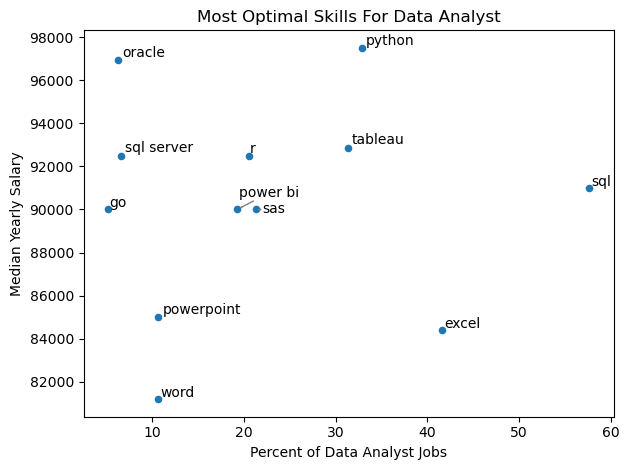

In [5]:
from adjustText import adjust_text

df_da_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary' )

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
 texts.append(plt.text(df_da_skills_high_demand['skill_percent']. iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt) )

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills For Data Analyst')

# Adjust layout and display plot
plt.tight_layout()
plt.show()

we can also do colour coding this different skills and further clean it up(also need to clean y axis as dollars and decimal and for x axis also we want %.. we already did them in previous exercises)

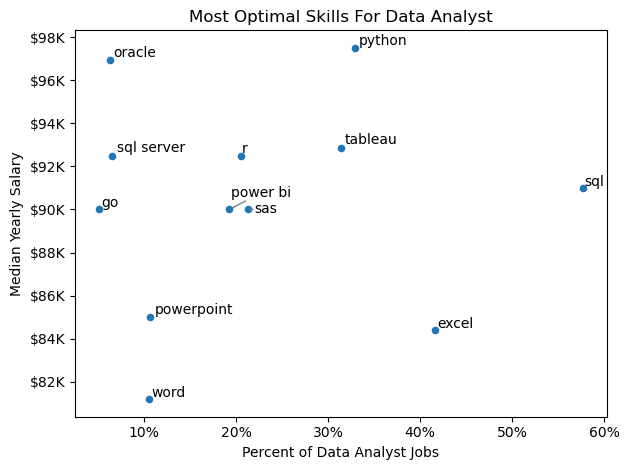

In [6]:
from adjustText import adjust_text

df_da_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary' )

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
 texts.append(plt.text(df_da_skills_high_demand['skill_percent']. iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt) )

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills For Data Analyst')


from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis. set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis. set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot
plt.tight_layout()
plt.show()

now before color coding 

we see that the data we have in our dataframe is inside multiple dictionaries if i want them all to come inside a singular dictionary then:-

In [7]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['ms access',
  'nuix',
  'cognos',
  'datarobot',
  'powerbi',
  'looker',
  'msaccess',
  'sheets',
  'spss',
  'spreadsheet',
  'splunk',
  'sas',
  'word',
  'alteryx',
  'qlik',
  'dax',
  'ssis',
  'esquisse',
  'powerpoint',
  'visio',
  'excel',
  'microstrategy',
  'tableau',
  'power bi',
  'sharepoint',
  'outlook',
  'ssrs',
  'sap'],
 'programming': ['php',
  'lua',
  'delphi',
  'java',
  'sass',
  'julia',
  'clojure',
  'visualbasic',
  'sql',
  'vba',
  'go',
  'cobol',
  'c#',
  'haskell',
  'assembly',
  'ruby',
  'sas',
  'typescript',
  'objective-c',
  'golang',
  'dart',
  'visual basic',
  'mongo',
  'javascript',
  'python',
  'vb.net',
  'css',
  'nosql',
  'powershell',
  'lisp',
  'perl',
  'kotlin',
  'mongodb',
  'fortran',
  'c++',
  'shell',
  'scala',
  't-sql',
  'apl',
  'bash',
  'elixir',
  'rust',
  'ocaml',
  'crystal',
  'groovy',
  'no-sql',
  'swift',
  'f#',
  'solidity',
  'erlang',
  'pascal',
  'matlab',
  'html',
  'c',
 

This code converts a dictionary into a pandas DataFrame, then explodes the 'skills' column, creating multiple rows for each 'technology' entry if it contains multiple skills.

In [8]:
pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

,technology,skills
0,analyst_tools,"[ms access, nuix, cognos, datarobot, powerbi, ..."
1,programming,"[php, lua, delphi, java, sass, julia, clojure,..."
2,cloud,"[snowflake, watson, bigquery, colocation, open..."
3,libraries,"[huggingface, qt, pandas, tidyr, pyspark, hugg..."
4,other,"[puppet, pulumi, ansible, jenkins, yarn, unrea..."
5,databases,"[elasticsearch, sql server, db2, couchbase, re..."
6,os,"[windows, ubuntu, centos, fedora, suse, linux,..."
7,async,"[asana, smartsheet, trello, airtable, jira, mi..."
8,webframeworks,"[django, jquery, angular.js, rubyon rails, nod..."
9,sync,"[twilio, webex, unify, google chat, microsoft ..."


we need to break this skills coloumn so we use explode on skills

In [9]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,ms access
0,analyst_tools,nuix
0,analyst_tools,cognos
0,analyst_tools,datarobot
0,analyst_tools,powerbi
...,...,...
9,sync,rocketchat
9,sync,ringcentral
9,sync,wire
9,sync,zoom


now we Merges two DataFrames, df_da_skills and df_technology, based on the columns 'job_skills' and 'skills' respectively, creating a new DataFrame df_da_skills_tech.

In [10]:
# merge df_skills_high_demand and df_technology
df_da_skills_tech = df_da_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_da_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


In [11]:
df_plot=df_da_skills_tech

now by seaborn

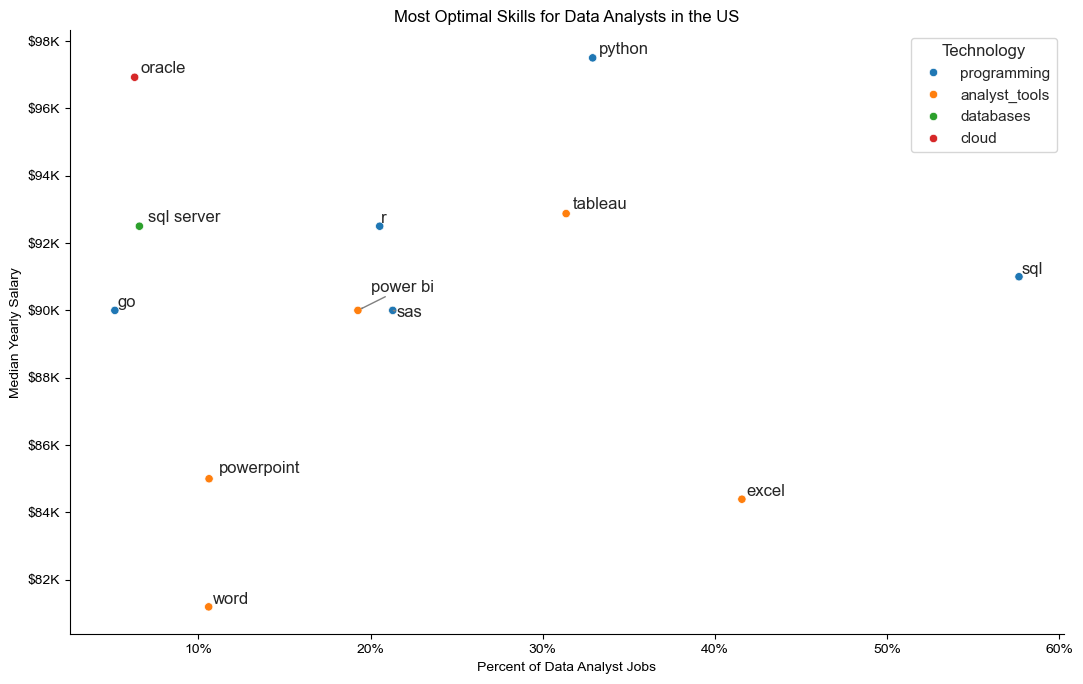

In [12]:
plt.figure(figsize=(11, 7)) # Increase figure size 
sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()

---

now for india

In [13]:
df_da_ind = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_da_ind = df_da_ind.dropna(subset=['salary_year_avg'])

df_da_ind_exploded = df_da_ind.explode('job_skills')

df_da_ind_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


In [14]:
# using df_DA find the count of skills and also the median salary for each skill
df_da_ind_skills = df_da_ind_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_da_ind_skills = df_da_ind_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

da_job_count = len(df_da_ind)  # Find count of Data Analyst jobs in US with salary info

df_da_ind_skills['skill_percent'] = df_da_ind_skills['skill_count'] / da_job_count * 100

df_da_ind_skills = df_da_ind_skills[df_da_ind_skills['skill_count'] > 0]

df_da_ind_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,96050.0,48.936170
excel,39,98500.0,41.489362
python,36,96050.0,38.297872
tableau,20,108087.5,21.276596
r,18,79200.0,19.148936
...,...,...,...
unify,1,79200.0,1.063830
unreal,1,105650.0,1.063830
visio,1,119250.0,1.063830


In [15]:
skill_percent = 5
df_da_ind_skills_high_demand = df_da_ind_skills[df_da_ind_skills['skill_percent' ] > skill_percent]

df_da_ind_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,96050.00,48.936170
excel,39,98500.00,41.489362
python,36,96050.00,38.297872
tableau,20,108087.50,21.276596
r,18,79200.00,19.148936
power bi,17,111175.00,18.085106
azure,15,93600.00,15.957447
aws,12,79200.00,12.765957
oracle,11,79200.00,11.702128


In [16]:
# merge df_skills_high_demand and df_technology
df_da_ind_skills_tech = df_da_ind_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_da_ind_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,46,96050.00,48.936170,programming,sql
1,39,98500.00,41.489362,analyst_tools,excel
2,36,96050.00,38.297872,programming,python
3,20,108087.50,21.276596,analyst_tools,tableau
4,18,79200.00,19.148936,programming,r
5,17,111175.00,18.085106,analyst_tools,power bi
6,15,93600.00,15.957447,cloud,azure
7,12,79200.00,12.765957,cloud,aws
8,11,79200.00,11.702128,cloud,oracle
9,11,111175.00,11.702128,libraries,spark


In [17]:
df_ind_plot=df_da_ind_skills_tech

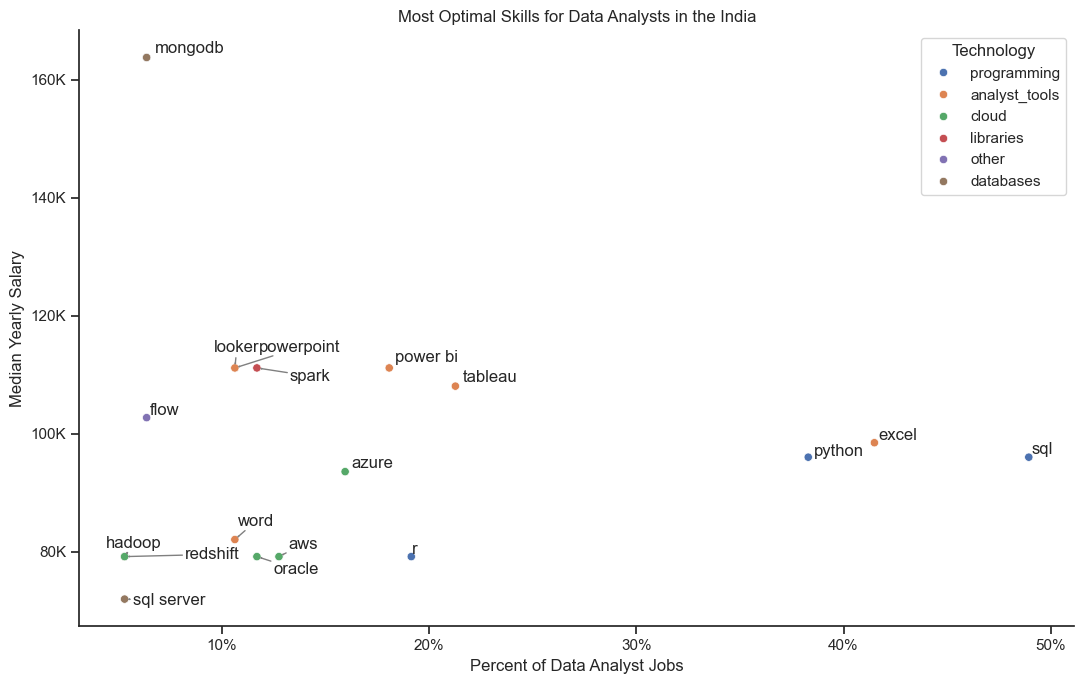

In [18]:
plt.figure(figsize=(11, 7)) # Increase figure size 
sns.scatterplot(
    data=df_ind_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_ind_skills_high_demand.index):
    texts.append(plt.text(df_da_ind_skills_high_demand['skill_percent'].iloc[i], df_da_ind_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the India')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()

---